# Tutorial: Non-Convex Rashomon Set Construction

This notebook demonstrates how to use `compute_nonconvex_rashomon_bounds`.

We will:
1. Load a trained **source actor** and use it as the first reference network.
2. Build a source-rollout Rashomon dataset.
3. Construct multiple convex Rashomon sets with a fixed iteration budget (`n_iters`) per set.
4. At each step, sample a new reference network from lower/upper bounds via Bernoulli(0.5).
5. Collect all lower/upper bounds (and optional checkpoints) for the non-convex union.


In [125]:
from __future__ import annotations

from pathlib import Path
import sys
import torch
import gymnasium as gym

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "experiments").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory.")


REPO_ROOT = '/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning' # find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.pipelines.behaviour_retention.lunarlander.core.env.env_factory import _make_lunarlander_env
from experiments.pipelines.behaviour_retention.lunarlander.core.env.task_loading import (
    _load_task_settings,
    _resolve_lunarlander_dynamics,
)
from experiments.pipelines.behaviour_retention.lunarlander.core.eval.evaluate_policy import _build_actor_from_state_dict
from experiments.pipelines.behaviour_retention.lunarlander.core.orchestration.run_paths import (
    default_outputs_root,
    default_task_settings_file,
    resolve_default_source_run_dir,
)
from experiments.pipelines.behaviour_retention.lunarlander.core.methods.adapt_rashomon import (
    compute_nonconvex_rashomon_bounds,
    create_source_rollout_rashomon_dataset,
)
from experiments.utils.rashomon_utils import plot_param_bounds_multi_set

%load_ext autoreload
%autoreload 2

print(f"Repo root: {REPO_ROOT}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning


In [ ]:
# Configuration
PIPELINE = "deterministic__default_to_sluggish_vehicle"
SEED = 1
DEVICE = "cpu"

# Non-convex Rashomon settings
N_CONVEX_SETS_BUDGET = 3
N_ITERS = 5000
MIN_HARD_SPEC = 1.0
AGGREGATION = "min"  # "min" or "mean"
INVERSE_TEMP_START = 10
INVERSE_TEMP_MAX = 1000
CHECKPOINT = 100
RETURN_CHECKPOINTS = True

# Dataset settings
RASHOMON_ROLLOUTS = 30

# Paths
TASK_SETTINGS_FILE = default_task_settings_file()
OUTPUTS_ROOT = default_outputs_root()


In [64]:
# Load one source actor and use it as the first reference network.
source_run_dir = resolve_default_source_run_dir(OUTPUTS_ROOT, PIPELINE, SEED)
source_actor_path = source_run_dir / "actor.pt"
if not source_actor_path.exists():
    raise FileNotFoundError(f"Source actor checkpoint not found: {source_actor_path}")

try:
    source_actor_state_dict = torch.load(source_actor_path, map_location="cpu", weights_only=False)
except TypeError:
    source_actor_state_dict = torch.load(source_actor_path, map_location="cpu")

if not isinstance(source_actor_state_dict, dict):
    raise TypeError(f"Expected state_dict dict, got {type(source_actor_state_dict)}")

source_actor = _build_actor_from_state_dict(source_actor_state_dict).to(DEVICE)
source_actor.eval()

n_params = sum(p.numel() for p in source_actor.parameters())
print(f"Using source run dir: {source_run_dir}")
print(f"Using source actor: {source_actor_path}")
print(f"Initial reference network params: {n_params}")


Using source run dir: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/experiments/pipelines/behaviour_retention/lunarlander/artifacts/runs/deterministic__default_to_sluggish_vehicle/seed_0/noadapt
Using source actor: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/experiments/pipelines/behaviour_retention/lunarlander/artifacts/runs/deterministic__default_to_sluggish_vehicle/seed_0/noadapt/actor.pt
Initial reference network params: 69380


In [65]:
# Build source-task environment config and create Rashomon dataset from source rollouts.
source_task_cfg = _load_task_settings(TASK_SETTINGS_FILE, PIPELINE, "source")
source_dynamics = _resolve_lunarlander_dynamics(source_task_cfg, cfg_name=f"{PIPELINE}:source")

env_id = str(source_task_cfg.get("env_id") or "LunarLander-v3")
source_gravity_raw = source_task_cfg.get("gravity")
source_gravity = None if source_gravity_raw is None else float(source_gravity_raw)
source_task_id = float(source_task_cfg.get("task_id", 0.0))
append_task_id = bool(source_task_cfg.get("append_task_id", True))

source_env_kwargs = {
    "gravity": source_gravity,
    "task_id": source_task_id,
    "append_task_id": append_task_id,
    **source_dynamics,
}

source_env = _make_lunarlander_env(env_id, render_mode=None, **source_env_kwargs)
if not isinstance(source_env.action_space, gym.spaces.Discrete):
    source_env.close()
    raise ValueError("This tutorial expects a discrete LunarLander action space.")

n_actions = int(source_env.action_space.n)
rashomon_dataset, rollout_lengths = create_source_rollout_rashomon_dataset(
    actor=source_actor,
    env=source_env,
    seed=SEED,
    n_actions=n_actions,
    rashomon_rollouts=1,
)
source_env.close()

print(f"Built Rashomon dataset with {len(rashomon_dataset)} samples")
print(f"Rollouts collected: {len(rollout_lengths)}")
print(f"Mean rollout length: {sum(rollout_lengths) / max(len(rollout_lengths), 1):.2f}")


Built Rashomon dataset with 295 samples
Rollouts collected: 1
Mean rollout length: 295.00


In [66]:
# Compute the non-convex Rashomon set as a union of convex sets.
all_bounds_l, all_bounds_u, checkpoints = compute_nonconvex_rashomon_bounds(
    actor=source_actor.to("cpu"),
    rashomon_dataset=rashomon_dataset,
    seed=SEED,
    n_iters=N_ITERS,
    min_hard_spec=MIN_HARD_SPEC,
    aggregation=AGGREGATION,
    inverse_temp_start=INVERSE_TEMP_START,
    inverse_temp_max=INVERSE_TEMP_MAX,
    checkpoint=CHECKPOINT,
    n_convex_sets_budget=N_CONVEX_SETS_BUDGET,
    return_checkpoints=RETURN_CHECKPOINTS,
)

print(f"Built {len(all_bounds_l)} convex Rashomon sets")
print(f"Returned upper-bound sets: {len(all_bounds_u)}")
if checkpoints is not None:
    print(f"Checkpoint records: {len(checkpoints)}")


Initial acc constraint violation: -0.0003 (Positive = violated)
Number of model parameters: 69380
Computing Rashomon set with limits: min_soft_acc_limit=0.50, min_hard_acc_limit=0.50
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=0.50


  0%|          | 0/5000 [00:00<?, ?it/s, size=0.20, obj=0.000, min_soft_acc=0.500]

100%|██████████| 5000/5000 [02:17<00:00, 36.45it/s, size=1180.36, obj=0.017, min_soft_acc=0.498]


Final bbox:  Obj=0.02,  Size=1180.36,  Min acc hard=0.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 50 checkpoints
Checkpoints sizes: ['135.69', '309.20', '468.27', '584.75', '697.60', '809.53', '920.42', '1027.16', '1135.56', '1167.82', '1168.09', '1168.36', '1168.65', '1168.93', '1169.22', '1169.51', '1169.80', '1170.10', '1170.39', '1170.70', '1171.00', '1171.31', '1171.62', '1171.93', '1172.25', '1172.56', '1172.88', '1173.18', '1173.49', '1173.81', '1174.12', '1174.44', '1174.76', '1175.08', '1175.40', '1175.71', '1176.03', '1176.35', '1176.68', '1177.01', '1177.34', '1177.67', '1178.00', '1178.34', '1178.68', '1179.00', '1179.34', '1179.68', '1180.02', '1180.36']
Checkpoint certificates: ['1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0

100%|██████████| 5000/5000 [02:05<00:00, 39.75it/s, size=5071.86, obj=0.073, min_soft_acc=0.500]


Final bbox:  Obj=0.07,  Size=5071.86,  Min acc hard=1.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 50 checkpoints
Checkpoints sizes: ['135.32', '314.90', '494.88', '652.44', '783.88', '901.82', '1011.71', '1119.36', '1220.80', '1324.07', '1426.71', '1523.46', '1624.02', '1721.68', '1822.42', '1919.06', '2018.55', '2110.71', '2210.82', '2307.62', '2400.99', '2497.67', '2595.49', '2683.76', '2778.63', '2874.02', '2957.34', '3049.85', '3141.64', '3233.81', '3328.55', '3410.11', '3500.96', '3593.94', '3685.21', '3778.51', '3862.65', '3955.31', '4048.24', '4141.23', '4228.39', '4321.45', '4411.54', '4506.14', '4598.49', '4692.67', '4785.05', '4880.59', '4977.87', '5071.86']
Checkpoint certificates: ['1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '1.00', '

100%|██████████| 5000/5000 [02:16<00:00, 36.63it/s, size=5542.58, obj=0.080, min_soft_acc=0.499]


Final bbox:  Obj=0.08,  Size=5542.58,  Min acc hard=1.00,  Min acc soft=0.50
Computing final certificates over 256 samples
Num cert samples: 256
Checkpointed every 100 iterations for a total of 50 checkpoints
Checkpoints sizes: ['135.94', '318.94', '501.45', '682.37', '837.32', '991.20', '1145.14', '1298.07', '1451.91', '1605.80', '1754.17', '1902.63', '2040.61', '2173.67', '2309.79', '2431.07', '2557.25', '2669.03', '2784.89', '2884.32', '2989.38', '3095.17', '3198.72', '3292.51', '3387.26', '3484.53', '3581.58', '3676.59', '3758.11', '3848.65', '3940.08', '4028.31', '4118.79', '4207.74', '4297.24', '4387.37', '4456.40', '4538.33', '4622.54', '4708.13', '4793.46', '4878.79', '4960.92', '5036.13', '5121.30', '5206.60', '5287.09', '5372.68', '5459.12', '5542.58']
Checkpoint certificates: ['1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '0.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '

In [67]:
# Inspect each convex set (certificate + width summary).
def width_summary(bounds_l, bounds_u):
    widths = torch.cat([(u - l).detach().cpu().reshape(-1) for l, u in zip(bounds_l, bounds_u)])
    return {
        "n_params": int(widths.numel()),
        "min": float(widths.min().item()),
        "mean": float(widths.mean().item()),
        "max": float(widths.max().item()),
    }

for i, (l_set, u_set) in enumerate(zip(all_bounds_l, all_bounds_u)):
    w = width_summary(l_set, u_set)
    cert_msg = "N/A"
    inv_temp_msg = "N/A"
    if checkpoints is not None:
        cert_msg = f"{checkpoints[i]['selected_certificate']:.6f}"
        inv_temp_msg = str(checkpoints[i]["selected_inverse_temperature"])
    print(
        f"Set {i}: cert={cert_msg}, T={inv_temp_msg}, "
        f"width[min/mean/max]=[{w['min']:.6f}, {w['mean']:.6f}, {w['max']:.6f}]"
    )


Set 0: cert=1.000000, T=89, width[min/mean/max]=[0.000000, 0.016367, 0.050158]
Set 1: cert=1.000000, T=89, width[min/mean/max]=[0.000000, 0.073103, 0.278701]
Set 2: cert=1.000000, T=89, width[min/mean/max]=[0.000000, 0.079887, 0.279601]


In [72]:
import importlib

import matplotlib.pyplot as plt
from experiments.utils import rashomon_utils
importlib.reload(rashomon_utils)
from experiments.utils.rashomon_utils import plot_param_bounds

# Choose 3 most varying parameters (from convex set 0) for a meaningful 3D view.
width_chunks = [(u - l).detach().flatten() for l, u in zip(all_bounds_l[0], all_bounds_u[0])]
global_widths = torch.cat(width_chunks)
top3_global = torch.topk(global_widths, k=3).indices.tolist()

# # Map global flat indices -> (tensor_idx, flat_idx)
# param_indices = []
# for gidx in top3_global:
#     rem = int(gidx)
#     for t_idx, t in enumerate(all_bounds_l[0]):
#         n = t.numel()
#         if rem < n:
#             param_indices.append((t_idx, rem))
#             break
#         rem -= n

# # Plot each convex Rashomon set in 3D using plot_param_bounds logic.
# for set_idx, (l_set, u_set) in enumerate(zip(all_bounds_l, all_bounds_u)):
#     plot_param_bounds(
#         param_lower_bounds=l_set,
#         param_upper_bounds=u_set,
#         param_indices=param_indices,
#         title=f"Convex Rashomon set #{set_idx} (3D)",
#         figsize=(6.0, 5.0),
#     )



Selected param_indices (from convex set 0): [(2, 33798), (2, 57862)]


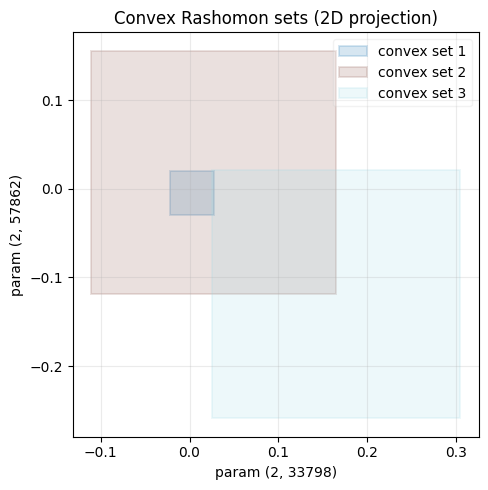

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Convex Rashomon sets (2D projection)'}, xlabel='param (2, 33798)', ylabel='param (2, 57862)'>)

In [71]:
# 2D: choose the two parameters with largest Rashomon width from convex set 0
width_chunks = [(u - l).detach().flatten() for l, u in zip(all_bounds_l[0], all_bounds_u[0])]
global_widths = torch.cat(width_chunks)
top2_global = torch.topk(global_widths, k=2).indices.tolist()

# Map global flat indices -> (tensor_idx, flat_idx)
param_indices = []
for gidx in top2_global:
    rem = int(gidx)
    for t_idx, t in enumerate(all_bounds_l[0]):
        n = t.numel()
        if rem < n:
            param_indices.append((t_idx, rem))
            break
        rem -= n

print("Selected param_indices (from convex set 0):", param_indices)

plot_param_bounds_multi_set(
    param_lower_bounds_sets=all_bounds_l,
    param_upper_bounds_sets=all_bounds_u,
    param_indices=param_indices,
    set_labels=[f"convex set {i+1}" for i in range(len(all_bounds_l))],
    # set_color="tab:blue",
    merge_cuboids=False,
)

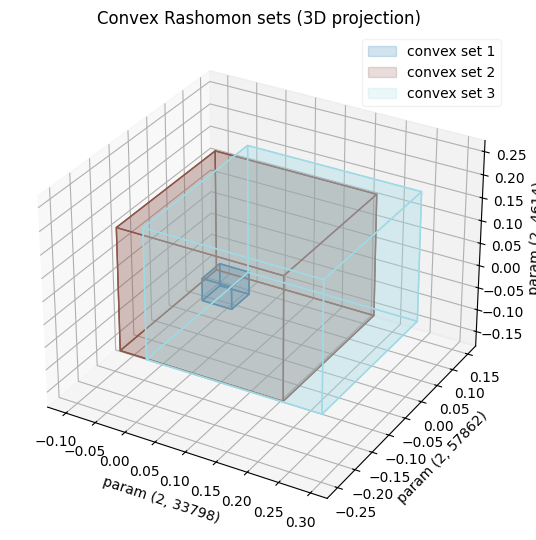

(<Figure size 700x550 with 1 Axes>,
 <Axes3D: title={'center': 'Convex Rashomon sets (3D projection)'}, xlabel='param (2, 33798)', ylabel='param (2, 57862)', zlabel='param (2, 4614)'>)

In [73]:
# 3D
top3_global = torch.topk(global_widths, k=3).indices.tolist()

# Map global flat indices -> (tensor_idx, flat_idx)
param_indices = []
for gidx in top3_global:
    rem = int(gidx)
    for t_idx, t in enumerate(all_bounds_l[0]):
        n = t.numel()
        if rem < n:
            param_indices.append((t_idx, rem))
            break
        rem -= n
plot_param_bounds_multi_set(
    param_lower_bounds_sets=all_bounds_l,
    param_upper_bounds_sets=all_bounds_u,
    param_indices=param_indices,
    set_labels=[f"convex set {i+1}" for i in range(len(all_bounds_l))],
    merge_cuboids=False,   # key new flag
    # set_color="tab:blue",
    alpha=0.2
)

## PPO-PGD
Use the computed non-convex Rahomon set to perform PPO-PGD for the downstream task.

In [126]:
import copy
from experiments.pipelines.behaviour_retention.lunarlander.core.methods.source_train import build_actor_critic
from experiments.utils.ppo_utils import PPOConfig, evaluate_with_success, ppo_train

# ── Downstream task config ────────────────────────────────────────────────────
downstream_task_cfg = _load_task_settings(TASK_SETTINGS_FILE, PIPELINE, "downstream")
downstream_dynamics = _resolve_lunarlander_dynamics(downstream_task_cfg, cfg_name=f"{PIPELINE}:downstream")
downstream_gravity   = downstream_task_cfg.get("gravity")
downstream_gravity   = None if downstream_gravity is None else float(downstream_gravity)
downstream_task_id   = float(downstream_task_cfg.get("task_id", 1.0))

downstream_env_kwargs = {
    "gravity":       downstream_gravity,
    "task_id":       downstream_task_id,
    "append_task_id": append_task_id,
    **downstream_dynamics,
}

print(f"Source task:     gravity={source_gravity}, task_id={source_task_id}")
print(f"Downstream task: gravity={downstream_gravity}, task_id={downstream_task_id}")

# ── Warm-start critic (optional) ──────────────────────────────────────────────
source_critic_path = source_run_dir / "critic.pt"
if source_critic_path.exists():
    obs_dim    = source_actor[0].in_features
    hidden_size = source_actor[0].out_features
    _, init_critic = build_actor_critic(obs_dim=obs_dim, n_actions=n_actions, hidden_size=hidden_size)
    try:
        init_critic.load_state_dict(torch.load(source_critic_path, map_location="cpu", weights_only=False))
    except TypeError:
        init_critic.load_state_dict(torch.load(source_critic_path, map_location="cpu"))
    print(f"Loaded source critic from {source_critic_path}")
else:
    init_critic = None
    print("No source critic checkpoint; critic will be randomly initialised.")

# ── PPO-PGD config ────────────────────────────────────────────────────────────
# Reduce PPO_TOTAL_TIMESTEPS for a quick demo; use 200_000 for full training.
PPO_TOTAL_TIMESTEPS = 50_000

ppo_cfg = PPOConfig(
    seed=SEED,
    total_timesteps=PPO_TOTAL_TIMESTEPS,
    eval_episodes=20,
    rollout_steps=2048,
    update_epochs=10,
    minibatch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    lr=3e-4,
    max_grad_norm=0.5,
    device=DEVICE,
    early_stop_success_rate_threshold=1.0,
    early_stop_min_steps=0,
)
print(f"\nPPO-PGD: total_timesteps={PPO_TOTAL_TIMESTEPS}, n_convex_sets={len(all_bounds_l)}")

# ── Run PPO-PGD ───────────────────────────────────────────────────────────────
# ppo_train projects the actor onto the nearest convex Rashomon subset after each
# gradient step. all_bounds_l / all_bounds_u are interval-major list[list[Tensor]],
# exactly the format returned by compute_nonconvex_rashomon_bounds.
train_env         = _make_lunarlander_env(env_id, render_mode=None, **downstream_env_kwargs)
early_stop_eval_env = _make_lunarlander_env(env_id, render_mode=None, **downstream_env_kwargs)

adapted_actor, adapted_critic, training_data, downstream_eval_records = ppo_train(  # type: ignore[assignment]
    train_env,
    ppo_cfg,
    actor_warm_start=source_actor,       # deep-copied internally
    critic_warm_start=init_critic,
    actor_param_bounds_l=all_bounds_l,
    actor_param_bounds_u=all_bounds_u,
    early_stop_eval_env=early_stop_eval_env,
    return_training_data=True,
    track_eval_params=True,
    return_eval_checkpoint_records=True,
)
# ppo_train closes both environments on return.

# ── Post-training evaluation ──────────────────────────────────────────────────
EVAL_EPISODES = 1

src_env = _make_lunarlander_env(env_id, render_mode=None, **source_env_kwargs)
src_mean, src_std, src_fail, src_success = evaluate_with_success(
    src_env, adapted_actor, episodes=EVAL_EPISODES, deterministic=True, device=DEVICE)
src_env.close()

ds_env = _make_lunarlander_env(env_id, render_mode=None, **downstream_env_kwargs)
ds_mean, ds_std, ds_fail, ds_success = evaluate_with_success(
    ds_env, adapted_actor, episodes=EVAL_EPISODES, deterministic=True, device=DEVICE)
ds_env.close()

print(f"Source task     ({EVAL_EPISODES} ep): mean={src_mean:.1f} ± {src_std:.1f} | "
      f"failure={src_fail:.3f} | success={src_success:.3f}")
print(f"Downstream task ({EVAL_EPISODES} ep): mean={ds_mean:.1f} ± {ds_std:.1f} | "
      f"failure={ds_fail:.3f} | success={ds_success:.3f}")


Source task:     gravity=None, task_id=0.0
Downstream task: gravity=None, task_id=1.0
Loaded source critic from /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/experiments/pipelines/behaviour_retention/lunarlander/artifacts/runs/deterministic__default_to_sluggish_vehicle/seed_0/noadapt/critic.pt

PPO-PGD: total_timesteps=50000, n_convex_sets=3
Use PGD: True
Using projected gradient descent with convex-set projection (num_sets=3, distance_norm=l2)
Pre-update check | Steps=0 | meanR=-37.1 +/- 0.0 | failure_rate=1.00 | success_rate=0.00
Steps=20480 | meanR=187.7 +/- 0.0 | elapsed=20.3s | failure_rate=0.00 | success_rate=1.00 | PGD projections=28916241
  [Early stop] updates=10 | step=20480 | meanR=187.71 (threshold=None) | failure_rate=0.00 (threshold=None) | success_rate=1.00 (threshold=1.0)
Final evaluation over 20 episodes: mean_reward=187.71 +/- 0.00 | failure_rate=0.00 | success_rate=1.00 | Total PGD projections during training: 28916241
Source task     (1 ep): mean=214.1 

In [130]:
[
    downstream_eval_records[i]['metrics']['success_rate']
    for i in range(len(downstream_eval_records))
]

[0.0, 1.0, 1.0]

#### Visualise the source NoAdapt actor vs the Rashomon actor

In [76]:
noadapt_params = list(source_actor.parameters())
rashomon_params = list(adapted_actor.parameters())

In [94]:
# Exact inequality (bitwise float comparison), then sort by absolute difference (desc)
diff_records = []  # (abs_diff, signed_diff, tensor_idx, flat_idx_in_tensor, global_idx)

offset = 0
for t_idx, (p_noadapt, p_rashomon) in enumerate(zip(noadapt_params, rashomon_params)):
    a = p_noadapt.detach().reshape(-1)
    b = p_rashomon.detach().reshape(-1)

    diff_flat = torch.nonzero(a != b, as_tuple=False).squeeze(1)
    if diff_flat.numel() > 0:
        signed_diff = (a[diff_flat] - b[diff_flat]).cpu()
        abs_diff = signed_diff.abs()

        for i, d, ad in zip(diff_flat.tolist(), signed_diff.tolist(), abs_diff.tolist()):
            diff_records.append((float(ad), float(d), t_idx, int(i), offset + int(i)))

    offset += a.numel()

# Sort descending by absolute difference
diff_records.sort(key=lambda x: x[0], reverse=True)

# Keep your original outputs, now sorted
diff_param_indices = [(t_idx, i) for _, _, t_idx, i, _ in diff_records]
diff_global_indices = [gidx for _, _, _, _, gidx in diff_records]

print(f"Number of differing parameters: {len(diff_param_indices)}")
diff_param_indices

Number of differing parameters: 17378


[(2, 5520),
 (0, 68),
 (0, 478),
 (0, 854),
 (0, 953),
 (0, 989),
 (0, 1592),
 (0, 1934),
 (0, 2091),
 (0, 2101),
 (0, 2186),
 (0, 2195),
 (0, 1624),
 (0, 1025),
 (0, 1932),
 (0, 438),
 (0, 557),
 (0, 872),
 (2, 2225),
 (2, 4594),
 (2, 5892),
 (2, 6582),
 (2, 8886),
 (2, 9419),
 (2, 10244),
 (2, 10500),
 (2, 12332),
 (2, 12885),
 (2, 15849),
 (2, 15925),
 (2, 17412),
 (2, 17717),
 (2, 20277),
 (2, 22532),
 (2, 22546),
 (2, 24068),
 (2, 25348),
 (2, 29138),
 (2, 29188),
 (2, 29364),
 (2, 30815),
 (2, 31029),
 (2, 31465),
 (2, 31748),
 (2, 32715),
 (2, 34281),
 (2, 34860),
 (2, 39648),
 (2, 42129),
 (2, 43385),
 (2, 46027),
 (2, 47455),
 (2, 48361),
 (2, 48843),
 (2, 50229),
 (2, 50665),
 (2, 52713),
 (2, 54367),
 (2, 55093),
 (2, 59184),
 (2, 60137),
 (2, 62162),
 (2, 62185),
 (2, 62468),
 (2, 63465),
 (2, 64260),
 (2, 64309),
 (2, 64516),
 (2, 65068),
 (4, 761),
 (2, 4437),
 (2, 7733),
 (2, 9961),
 (2, 11509),
 (2, 28420),
 (2, 29161),
 (2, 36447),
 (2, 40825),
 (2, 41055),
 (2, 50921)

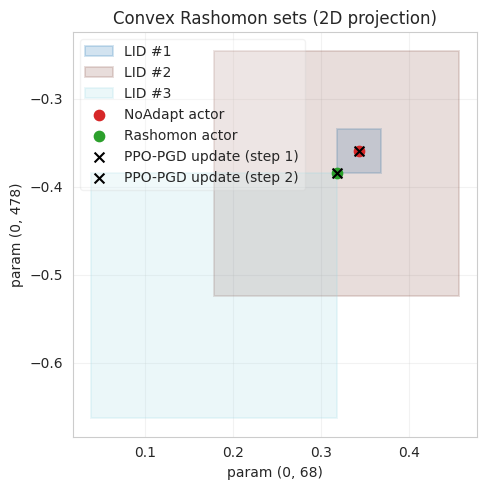

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Convex Rashomon sets (2D projection)'}, xlabel='param (0, 68)', ylabel='param (0, 478)'>)

In [142]:
# 2D
# top2_global = torch.topk(global_widths, k=2).indices.tolist()

# # Map global flat indices -> (tensor_idx, flat_idx)
# param_indices = []
# for gidx in top2_global:
#     rem = int(gidx)
#     for t_idx, t in enumerate(all_bounds_l[0]):
#         n = t.numel()
#         if rem < n:
#             param_indices.append((t_idx, rem))
#             break
#         rem -= n

param_indices = diff_param_indices[1:3]

# Scatter points (NoAdapt and Rashomon actor params) on top of the convex sets for visual comparison.
noadapt_param_coordinates = tuple([
    noadapt_params[idx[0]].detach().flatten()[idx[1]]
    for idx in param_indices
])
rashomon_param_coordinates = tuple([
    rashomon_params[idx[0]].detach().flatten()[idx[1]]
    for idx in param_indices
])

scatter_points = [
    {'coordinates': noadapt_param_coordinates, 'label': 'NoAdapt actor', 'color': 'tab:red'},
    {'coordinates': rashomon_param_coordinates, 'label': 'Rashomon actor', 'color': 'tab:green'},
]

# Add PPO-PGD iterates as additional scatter points.
downstream_adaptation_params_evolution_coordinates = [
    list(record['params'].values())[0]
    for record in downstream_eval_records
]
for i in range(len(downstream_eval_records[:-1])):
    cur_params = list(downstream_eval_records[i]['params'].values())
    cur_coordinates = tuple([
        cur_params[idx[0]].detach().flatten()[idx[1]]
        for idx in param_indices
    ])
    scatter_points.append({
        'coordinates': cur_coordinates,
        'label': f'PPO-PGD update (step {i+1})',
        'color': 'black', 'size': 50, 'alpha': 1.0, 'marker':'x'
    })

plot_param_bounds_multi_set(
    param_lower_bounds_sets=all_bounds_l,
    param_upper_bounds_sets=all_bounds_u,
    param_indices=param_indices,
    scatter_points=scatter_points,
    set_labels=[f"LID #{i+1}" for i in range(len(all_bounds_l))],
    merge_cuboids=False,   # key new flag
    # set_color="tab:blue",
    alpha=0.2
)

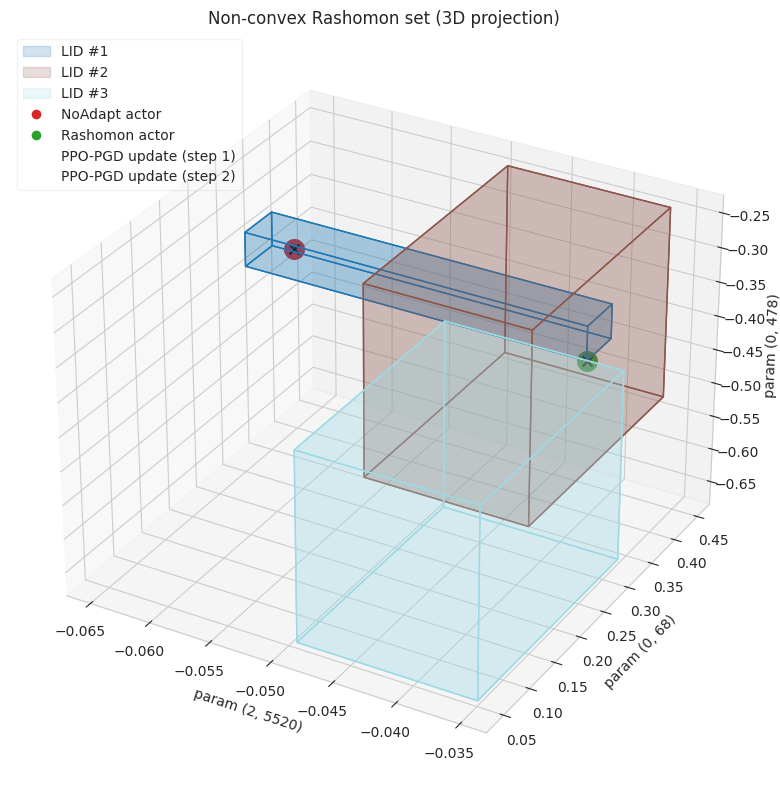

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: title={'center': 'Non-convex Rashomon set (3D projection)'}, xlabel='param (2, 5520)', ylabel='param (0, 68)', zlabel='param (0, 478)'>)

In [143]:
# 3D
# top3_global = torch.topk(global_widths, k=3).indices.tolist()

# # Map global flat indices -> (tensor_idx, flat_idx)
# param_indices = []
# for gidx in top3_global:
#     rem = int(gidx)
#     for t_idx, t in enumerate(all_bounds_l[0]):
#         n = t.numel()
#         if rem < n:
#             param_indices.append((t_idx, rem))
#             break
#         rem -= n
import seaborn as sns
sns.set_style("whitegrid")
param_indices = diff_param_indices[:3]

# Scatter points (NoAdapt and Rashomon actor params) on top of the convex sets for visual comparison.
noadapt_param_coordinates = tuple([
    noadapt_params[idx[0]].detach().flatten()[idx[1]]
    for idx in param_indices
])
rashomon_param_coordinates = tuple([
    rashomon_params[idx[0]].detach().flatten()[idx[1]]
    for idx in param_indices
])
scatter_points = [
    {
        'coordinates': noadapt_param_coordinates, 
        'label': 'NoAdapt actor', 
        'color': 'tab:red', 'size': 200, 
    },
    {
        'coordinates': rashomon_param_coordinates, 
        'label': 'Rashomon actor',
          'color': 'tab:green', 'size': 200
    },
]

# Add PPO-PGD iterates as additional scatter points.
downstream_adaptation_params_evolution_coordinates = [
    list(record['params'].values())[0]
    for record in downstream_eval_records
]
for i in range(len(downstream_eval_records[:-1])):
    cur_params = list(downstream_eval_records[i]['params'].values())
    cur_coordinates = tuple([
        cur_params[idx[0]].detach().flatten()[idx[1]]
        for idx in param_indices
    ])
    scatter_points.append({
        'coordinates': cur_coordinates,
        'label': f'PPO-PGD update (step {i+1})',
        'color': 'black', 'size': 50, 'alpha': 1.0, 'marker':'x'
    })

plot_param_bounds_multi_set(
    param_lower_bounds_sets=all_bounds_l,
    param_upper_bounds_sets=all_bounds_u,
    param_indices=param_indices,
    scatter_points=scatter_points,
    # Plotting settings
    figsize=(8, 8),
    title="Non-convex Rashomon set (3D projection)",
    set_labels=[f"LID #{i+1}" for i in range(len(all_bounds_l))],
    merge_cuboids=False,   # key new flag
    # set_color="tab:blue",
    alpha=0.2
)

## Save

In [54]:
# # Optional: save tutorial outputs.
# out_dir = OUTPUTS_ROOT / PIPELINE / f"seed_{SEED}" / "tutorial_nonconvex_rashomon_set"
# out_dir.mkdir(parents=True, exist_ok=True)
# out_path = out_dir / "nonconvex_rashomon_bounds.pt"

# torch.save(
#     {
#         "config": {
#             "pipeline": PIPELINE,
#             "seed": SEED,
#             "n_iters": N_ITERS,
#             "n_convex_sets_budget": N_CONVEX_SETS_BUDGET,
#             "min_hard_spec": MIN_HARD_SPEC,
#             "aggregation": AGGREGATION,
#             "inverse_temp_start": INVERSE_TEMP_START,
#             "inverse_temp_max": INVERSE_TEMP_MAX,
#             "checkpoint": CHECKPOINT,
#             "rashomon_rollouts": RASHOMON_ROLLOUTS,
#             "source_actor_path": str(source_actor_path),
#         },
#         "nonconvex_bounds_l": all_bounds_l,
#         "nonconvex_bounds_u": all_bounds_u,
#         "checkpoints": checkpoints,
#     },
#     out_path,
# )

# print(f"Saved tutorial artifact: {out_path}")
